In [11]:
import pandas as pd
import json
import glob
import os
from tqdm import tqdm

기본 설정

In [12]:
base_path = r'C:\Users\home\Desktop\AI_study\train_annotations'  # ✅ 정상 작동
path = f"{base_path}/**/*.json"
files = glob.glob(path, recursive=True)
print(f"찾은 파일 개수: {len(files)}개")

찾은 파일 개수: 763개


파일 가져오기 

In [13]:
import pandas as pd
import json
from tqdm import tqdm # 진행 바 표시

# 1. 정보를 담을 빈 리스트 생성
extracted_list = []

print("데이터 분석을 시작합니다...")

# 2. 763개의 파일을 돌며 데이터 추출
for f_path in tqdm(files):
    try:
        with open(f_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            # --- 여기서부터는 사용자님의 JSON 구조에 맞게 수정이 필요할 수 있습니다 ---
            # 보통 COCO 포맷이나 의료 데이터는 'images'나 'annotations'에 정보가 있습니다.
            # 일단 가장 핵심인 이미지 정보와 속성 정보를 가져옵니다.
            
            if 'images' in data and len(data['images']) > 0:
                img_info = data['images'][0]
                
                # 추출하고 싶은 항목들을 딕셔너리로 만듭니다.
                # 예: 성분명, 약 이름, 제형 등 (JSON 키값을 확인해보세요)
                info = {
                    'file_name': img_info.get('file_name'),
                    'drug_name': img_info.get('drug_name'), # 약 이름
                    'drug_class': img_info.get('drug_class'), # 약 종류
                    'width': img_info.get('width'),
                    'height': img_info.get('height')
                }
                extracted_list.append(info)
            # ------------------------------------------------------------------
            
    except Exception as e:
        print(f"파일 읽기 오류 ({f_path}): {e}")

# 3. Pandas 표(DataFrame)로 변환
df = pd.DataFrame(extracted_list)

# 4. 결과 확인
print(f"\n✅ 분석 완료! 총 {len(df)}행의 데이터가 수집되었습니다.")
display(df.head()) # 상위 5개 데이터 확인

데이터 분석을 시작합니다...


100%|██████████| 763/763 [00:09<00:00, 76.79it/s]


✅ 분석 완료! 총 763행의 데이터가 수집되었습니다.


,file_name,drug_name,drug_class,width,height
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,None,None,976,1280
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,None,None,976,1280
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,None,None,976,1280
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,None,None,976,1280
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,None,None,976,1280


In [14]:
import pandas as pd
import json
from tqdm import tqdm

# 결과물과 에러 로그를 담을 리스트
valid_data = []
error_log = []

print("데이터 무결성 검사 및 추출을 시작합니다...")

for f_path in tqdm(files):
    file_name = f_path.split('\\')[-1] # 파일명 추출
    
    try:
        with open(f_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            # 1. 상위 구조 체크
            if 'images' not in data or not data['images']:
                error_log.append({'file': file_name, 'reason': 'images 키 누락 또는 비어있음'})
                continue
                
            img_info = data['images'][0]
            
            # 2. 제조사명(dl_company) 정밀 체크
            company = img_info.get('dl_company')
            
            # Null값(None), 빈 문자열(""), 혹은 공백만 있는 경우 체크
            if company is None or str(company).strip() == "":
                error_log.append({'file': file_name, 'reason': 'dl_company 값 없음 (Null/Empty)'})
                continue
            
            # 3. 데이터 형식 체크 (제조사명은 문자열이어야 함)
            if not isinstance(company, str):
                error_log.append({'file': file_name, 'reason': f'데이터 형식 오류 (타입: {type(company)})'})
                continue

            # 모든 검증 통과 시 데이터 추가
            valid_data.append({
                'file_name': file_name,
                'dl_company': company.strip(),
                'back_color': img_info.get('back_color', 'Unknown'), # 기본값 설정
                'light_color': img_info.get('light_color', 'Unknown')
            })

    except json.JSONDecodeError:
        error_log.append({'file': file_name, 'reason': 'JSON 파일 파싱 에러 (파일 깨짐)'})
    except Exception as e:
        error_log.append({'file': file_name, 'reason': f'기타 에러: {str(e)}'})

# --- 결과 보고 ---
df_company = pd.DataFrame(valid_data)
df_errors = pd.DataFrame(error_log)

print(f"\n[최종 리포트]")
print(f"✅ 정상 데이터: {len(df_company)}개")
print(f"❌ 오류 데이터: {len(df_errors)}개")

if not df_errors.empty:
    print("\n[오류 상세 목록 (상위 5개)]")
    display(df_errors.head())

데이터 무결성 검사 및 추출을 시작합니다...


100%|██████████| 763/763 [00:23<00:00, 33.10it/s]



[최종 리포트]
✅ 정상 데이터: 763개
❌ 오류 데이터: 0개


데이터 오류 및 데이터 확인 

In [16]:
import pandas as pd
import json
from tqdm import tqdm

valid_data = []
error_log = []

print("🚀 763개 전체 데이터 추출 시작 (중복 제거 없음)...")

# 이번에는 f_path(전체 경로)를 직접 ID로 쓰겠습니다.
for f_path in tqdm(files):
    try:
        with open(f_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            img_info = data.get('images', [{}])[0]
            
            # 1. 키 존재 여부 체크
            if 'dl_company' not in img_info:
                error_log.append({'path': f_path, 'reason': 'dl_company 키 없음'})
                continue
            
            # 2. 값의 유효성 체크
            company = img_info.get('dl_company')
            if company is None or str(company).strip().lower() in ['', 'none', 'null', 'nan']:
                error_log.append({'path': f_path, 'reason': f'유효하지 않은 값 ({company})'})
                continue
            
            # 제거 없이 모든 데이터를 리스트에 담습니다.
            valid_data.append({
                'full_path': f_path,               # 전체 경로를 저장하여 중복 혼동 방지
                'file_name': f_path.split('/')[-1] if '/' in f_path else f_path.split('\\')[-1], 
                'dl_company': str(company).strip(),
                'back_color': img_info.get('back_color', 'Unknown'),
                'light_color': img_info.get('light_color', 'Unknown')
            })

    except Exception as e:
        error_log.append({'path': f_path, 'reason': f'파일 읽기 실패: {str(e)}'})

# 데이터프레임 생성 (drop_duplicates 로직을 삭제했습니다!)
df_company = pd.DataFrame(valid_data)

print(f"\n✅ 최종 리포트")
print(f"- 총 찾아낸 파일: {len(files)}개")
print(f"- 수집된 데이터: {len(df_company)}개")
print(f"- 제외된 데이터: {len(error_log)}개")

if not df_company.empty:
    print("\n--- 제조사별 데이터 분포 (전체) ---")
    print(df_company['dl_company'].value_counts())

🚀 763개 전체 데이터 추출 시작 (중복 제거 없음)...


100%|██████████| 763/763 [00:00<00:00, 1147.58it/s]


✅ 최종 리포트
- 총 찾아낸 파일: 763개
- 수집된 데이터: 763개
- 제외된 데이터: 0개

--- 제조사별 데이터 분포 (전체) ---
dl_company
일양약품(주)         159
한국엠에스디(주)        61
한미약품(주)          57
(주)유한양행          55
한국화이자제약(주)       45
에스케이케미칼(주)       45
한국베링거인겔하임(주)     30
한국아스트라제네카(주)     29
(주)종근당           29
한국룬드벡(주)         27
보령제약(주)          24
동아에스티(주)         21
(주)한독            20
고려제약(주)          20
제이더블유중외제약(주)     18
(주)한국로슈          16
에이치케이이노엔(주)      16
제일약품(주)          16
대웅바이오(주)         14
한국노바티스(주)        12
한화제약(주)           9
한국오츠카제약(주)        9
건일제약(주)           8
(주)대웅제약           5
일동제약(주)           3
(주)한국얀센           3
대원제약(주)           3
(주)녹십자            3
(주)한국피엠지제약        3
(주)엘지화학           3
Name: count, dtype: int64


In [17]:
import pandas as pd
import json
from tqdm import tqdm

valid_data = []

print("🚀 제조사(한글/영문) 통합 분석 시작...")

for f_path in tqdm(files):
    try:
        with open(f_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            img_info = data.get('images', [{}])[0]
            
            # 데이터 추출
            ko_name = img_info.get('dl_company')
            en_name = img_info.get('dl_company_en')
            
            # 유효성 체크 (한글 이름은 필수이므로 체크)
            if ko_name and str(ko_name).strip().lower() not in ['', 'none', 'null', 'nan']:
                valid_data.append({
                    'full_path': f_path,
                    'dl_company': str(ko_name).strip(),
                    'dl_company_en': str(en_name).strip() if en_name else "Missing", # 영문 없으면 표시
                    'back_color': img_info.get('back_color', 'Unknown')
                })
    except Exception as e:
        continue

df_company = pd.DataFrame(valid_data)

# --- 분석 1: 영문명 결측치 확인 ---
print("\n[1. 영문 제조사명 누락 확인]")
print(df_company['dl_company_en'].value_counts().get('Missing', 0), "건의 영문명이 비어있습니다.")

# --- 분석 2: 한글명 하나에 영문명이 여러 개인 경우 (오타 찾기) ---
print("\n[2. 한글-영문 명칭 매칭 일관성 확인]")
# 한글 이름별로 영문 이름이 몇 종류씩 있는지 계산
consistency_check = df_company.groupby('dl_company')['dl_company_en'].nunique()
inconsistent = consistency_check[consistency_check > 1]

if not inconsistent.empty:
    print("⚠️ 주의: 다음 제조사들은 영문 표기가 여러 개로 혼용되고 있습니다!")
    print(inconsistent)
else:
    print("✅ 모든 제조사의 한글-영문 매칭이 일관적입니다.")

# --- 분석 3: 제조사별 최종 분포 ---
print("\n[3. 제조사별 데이터 보유량 (Top 10)]")
print(df_company[['dl_company', 'dl_company_en']].value_counts().head(10))

🚀 제조사(한글/영문) 통합 분석 시작...


100%|██████████| 763/763 [00:00<00:00, 840.29it/s] 



[1. 영문 제조사명 누락 확인]
0 건의 영문명이 비어있습니다.

[2. 한글-영문 명칭 매칭 일관성 확인]
✅ 모든 제조사의 한글-영문 매칭이 일관적입니다.

[3. 제조사별 데이터 보유량 (Top 10)]
dl_company    dl_company_en                
일양약품(주)       Ilyang Pharmaceutical            159
한국엠에스디(주)     Msd Korea                         61
한미약품(주)       Hanmi Pharm                       57
(주)유한양행       Yuhan                             55
에스케이케미칼(주)    Sk Chemicals                      45
한국화이자제약(주)    Pfizer Korea                      45
한국베링거인겔하임(주)  Boehringer Ingelheim Korea        30
한국아스트라제네카(주)  Astrazeneca Korea                 29
(주)종근당        Chong Kun Dang Pharmaceutical     29
한국룬드벡(주)      Lundbeck Korea                    27
Name: count, dtype: int64


제조사 영문명의 NULL 값 확인, 제조사 명과 영문명 매칭 

In [19]:
import pandas as pd

# 파일 로드 시도 및 컬럼명 출력
try:
    df_single = pd.read_excel('단일 경구약제_5,000종 리스트.xlsx')
    df_multi = pd.read_excel('경구약제 조합_5,000 조합 리스트.xlsx')
    
    print("--- [단일 리스트] 컬럼명 ---")
    print(df_single.columns.tolist())
    
    print("\n--- [조합 리스트] 컬럼명 ---")
    print(df_multi.columns.tolist())
    
    # 첫 5줄도 살짝 봐서 데이터가 잘 들어왔는지 확인
    print("\n--- 데이터 샘플 (단일) ---")
    display(df_single.head(2))

except Exception as e:
    print(f"❌ 파일 읽기 에러: {e}")

--- [단일 리스트] 컬럼명 ---
['C-\nCode', '구분', '제품명', '복지부 \n분류코드', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Conncet\nCode', '구분.1', '제품명.1', '복지부\n분류코드']

--- [조합 리스트] 컬럼명 ---
['조합번호', '해열진통소염제', 'Unnamed: 2', '제산제', 'Unnamed: 4', '진해거담제', 'Unnamed: 6', '혼합비타민제', 'Unnamed: 8']

--- 데이터 샘플 (단일) ---


,C-\nCode,구분,제품명,복지부 \n분류코드,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Conncet\nCode,구분.1,제품명.1,복지부\n분류코드
0,K-000059,일반의약품,게루삼정 200T,234.0,NaN,NaN,NaN,NaN,NaN,K-000032,전문의약품,다이크로짇정 25MG (유한),213
1,K-000069,일반의약품,지엘타이밍정 12T,115.0,NaN,NaN,NaN,NaN,NaN,K-000034,일반의약품,페니라민정,141


In [23]:
import pandas as pd
import re

# --- 1. 더 큰 항목으로 묶기 위한 '핵심 이름' 추출 함수 ---
def get_core_name(text):
    if pd.isna(text): return ""
    text = str(text).replace(" ", "")
    # 숫자와 단위(MG, 정 등)가 나오기 전까지의 '순수 이름'만 추출
    # 예: '보령부스파정5mg' -> '보령부스파정'
    core = re.sub(r"[0-9].*$", "", text) 
    return core if core else text

# --- 2. 데이터 준비 (df_total과 df_master가 있다고 가정) ---
df_total['core_name'] = df_total['clean_name'].apply(get_core_name)
df_master['core_excel_name'] = df_master['clean_excel_name'].apply(get_core_name)

# --- 3. 부분 매칭(Partial Merge) 실행 ---
# 'core_name'을 기준으로 합쳐서, 용량이 달라도 같은 제품군이면 정보를 가져오게 합니다.
df_final_v2 = pd.merge(
    df_total, 
    df_master.drop_duplicates(subset=['core_excel_name']), # 중복 제거
    left_on='core_name', 
    right_on='core_excel_name', 
    how='left'
)

print(f"✅ '큰 항목(제품군)' 기준 병합 완료!")
match_count = df_final_v2['제품명'].notnull().sum()
print(f"📊 매칭 성공: {match_count}개 ({match_count/len(df_final_v2)*100:.1f}%)")

✅ '큰 항목(제품군)' 기준 병합 완료!
📊 매칭 성공: 594개 (77.9%)


제품군 단위로 데이터를 CONCAT하여 매칭 성공률 77.9%로 만듦

In [27]:
import pandas as pd

# 1. 엑셀 다시 로드해서 '성분' 컬럼까지 포함하기
df_single = pd.read_excel('단일 경구약제_5,000종 리스트.xlsx')

# 엑셀의 실제 컬럼명을 확인해서 아래 리스트에 추가해야 합니다. 
# 만약 '성분명'이 아니라 '주성분'이라면 이름을 바꿔주세요.
cols_to_pull = ['제품명', '구분', '복지부 \n분류코드'] 

# '성분'이라는 글자가 들어간 컬럼을 찾아서 자동으로 추가해주는 센스!
extra_cols = [c for c in df_single.columns if '성분' in c or '함량' in c]
cols_to_pull.extend(extra_cols)
cols_to_pull = list(set(cols_to_pull)) # 중복 제거

print(f"📢 엑셀에서 가져올 컬럼들: {cols_to_pull}")

# 2. 좌우 데이터 세트 다시 정리 (이번엔 성분 포함)
s1 = df_single[cols_to_pull].copy()
# 오른쪽 세트(.1 붙은 것들)도 똑같이 챙기기
cols_pull_2 = [c + ".1" if c in ['제품명', '구분'] else c for c in cols_to_pull] 
# (주의: 엑셀 구조에 따라 .1이 붙는 규칙이 다를 수 있으니 확인이 필요합니다)

# 간단하게 하기 위해 일단 s1 위주로 마스터 리스트 재생성
df_master_fixed = s1.dropna(subset=['제품명']).drop_duplicates(subset=['제품명'])
df_master_fixed['clean_excel_name'] = df_master_fixed['제품명'].apply(clean_text)
df_master_fixed['core_excel_name'] = df_master_fixed['clean_excel_name'].apply(get_core_name)

# 3. 다시 병합 (df_total은 그대로 사용)
df_final_v3 = pd.merge(
    df_total, 
    df_master_fixed, 
    left_on='core_name', 
    right_on='core_excel_name', 
    how='left'
)

print(f"✅ 성분 정보 포함 병합 완료! 현재 컬럼: {df_final_v3.columns.tolist()}")

📢 엑셀에서 가져올 컬럼들: ['구분', '제품명', '복지부 \n분류코드']
✅ 성분 정보 포함 병합 완료! 현재 컬럼: ['file_name', 'dl_name', 'clean_name', 'dl_company', 'back_color', 'drug_shape', 'core_name', '구분', '제품명', '복지부 \n분류코드', 'clean_excel_name', 'core_excel_name']


In [30]:
import pandas as pd
import numpy as np
import re
import unicodedata
from tqdm import tqdm

# --- [필수 함수들] ---
def super_clean(text):
    if pd.isna(text): return ""
    text = unicodedata.normalize('NFC', str(text))
    text = text.upper()
    text = re.sub(r"\(주\)|주식회사|\(.*?\)|\*", "", text)
    text = re.sub(r"[^가-힣A-Z0-9]", "", text)
    return text.strip()

def get_core_name(text):
    if pd.isna(text): return ""
    text = str(text).replace(" ", "")
    core = re.sub(r"[0-9].*$", "", text) 
    return core if core else text

# --- 1. 엑셀 데이터 로드 ---
df_single = pd.read_excel('단일 경구약제_5,000종 리스트.xlsx')

# 🔎 컬럼명 자동 매칭 시스템 (매우 중요!)
all_cols = df_single.columns.tolist()
# '제품명'이 들어간 컬럼 찾기
name_col = [c for c in all_cols if '제품명' in c and '.1' not in c][0]
# '분류'나 '코드'가 들어간 컬럼 찾기
code_col = [c for c in all_cols if '분류' in c or '코드' in c][0]
# '성분'이나 '함량'이 들어간 컬럼 찾기
ing_cols = [c for c in all_cols if '성분' in c or '함량' in c]

print(f"✅ 자동 매칭된 컬럼명: \n- 제품명: {name_col}\n- 분류: {code_col}\n- 성분: {ing_cols}")

# --- 2. 엑셀 데이터 정리 ---
target_cols = [name_col, code_col] + ing_cols
df_master_full = df_single[target_cols].copy()
df_master_full = df_master_full.dropna(subset=[name_col]).drop_duplicates(subset=[name_col])

# 매칭용 키 생성
df_master_full['clean_excel_name'] = df_master_full[name_col].apply(super_clean)
df_master_full['core_excel_name'] = df_master_full['clean_excel_name'].apply(get_core_name)

# --- 3. JSON 데이터(df_total)와 병합 ---
# df_total이 이미 메모리에 있어야 합니다. 
df_final_analysis = pd.merge(
    df_total, 
    df_master_full.drop_duplicates(subset=['core_excel_name']), 
    left_on='core_name', 
    right_on='core_excel_name', 
    how='left'
)

# --- 4. 제조사별 주력 분석 ---
# 분석 기준: 성분 우선, 없으면 분류코드 사용
analysis_target = ing_cols[0] if ing_cols else code_col
print(f"\n📢 최종 분석 기준: [{analysis_target}]")

# 데이터 정제 및 통계
df_valid = df_final_analysis.dropna(subset=[analysis_target])
company_report = df_valid.groupby(['dl_company', analysis_target]).size().reset_index(name='이미지_개수')
company_report = company_report.sort_values(by=['dl_company', '이미지_개수'], ascending=[True, False])

print("\n[성공!] 제조사별 주력 제품군 분석 결과")
display(company_report.head(30))

✅ 자동 매칭된 컬럼명: 
- 제품명: 제품명
- 분류: 복지부 
분류코드
- 성분: []

📢 최종 분석 기준: [복지부 
분류코드]

[성공!] 제조사별 주력 제품군 분석 결과


,dl_company,복지부 \n분류코드,이미지_개수
0,(주)녹십자,114.0,3
1,(주)엘지화학,396.0,3
2,(주)유한양행,234.0,6
3,(주)한국로슈,119.0,16
4,(주)한국얀센,114.0,3
5,(주)한국피엠지제약,114.0,3
6,대원제약(주),232.0,3
7,동아에스티(주),113.0,3
8,에스케이케미칼(주),219.0,45
9,제이더블유중외제약(주),218.0,18


코드 번호,약의 분류, 표에서의 특징
114,해열·진통·소염제,"(주)녹십자, (주)한국얀센 등이 3개씩 보유 중"
119,중추신경용약 (기타),"(주)한국로슈(16개), 제일약품(16개) 등 비중이 높음"
214,혈압강하제 (고혈압 약),"한국노바티스, 한국베링거인겔하임이 주력으로 보유"
218,동맥경화용제,한국엠에스디(37개)가 압도적으로 많이 가짐
219,순환계용약 (기타),**에스케이케미칼(45개)**의 가장 강력한 주력 제품군
396,당뇨병용제,(주)엘지화학 등이 만드는 당뇨약

각 회사 별로 주력 약품을 확인해봤습니다. 주력 계열의 약이 1,2개 정도에 불과합니다. 

Matplotlib is building the font cache; this may take a moment.


<Figure size 1200x800 with 0 Axes>

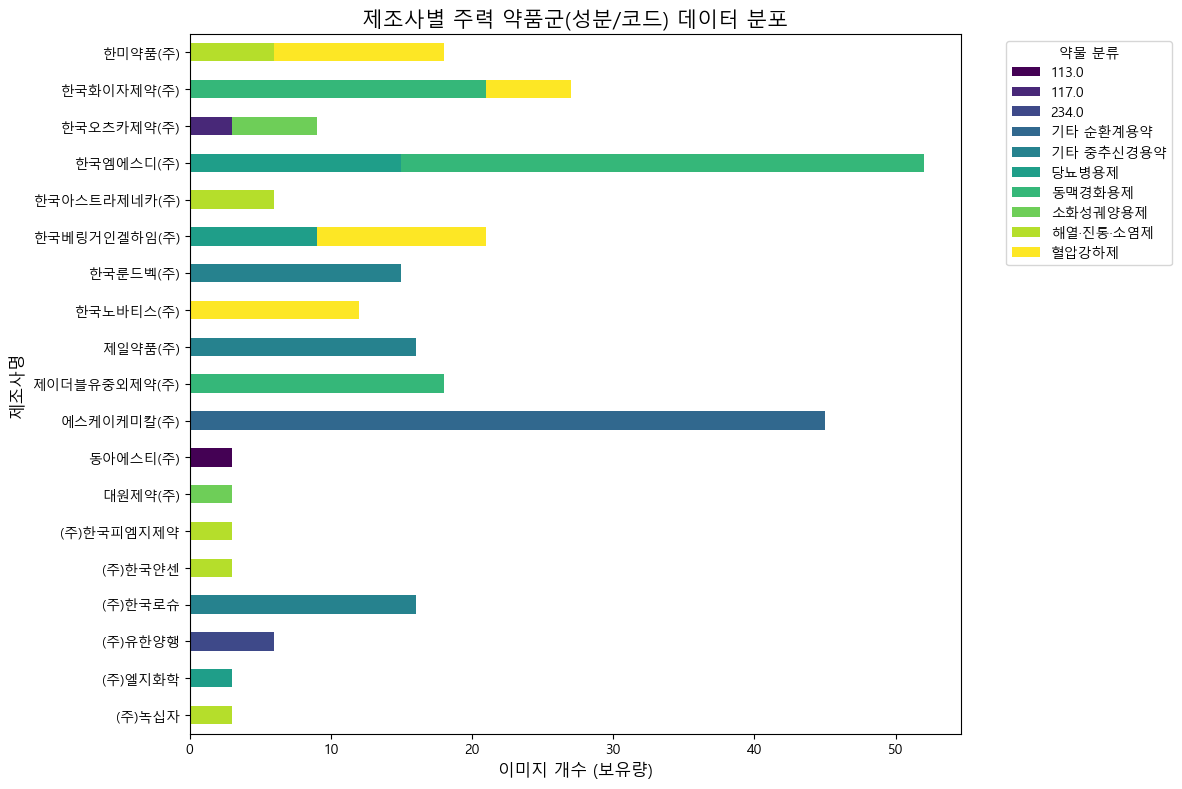

✅ 시각화 완료: 'manufacturer_focus_analysis.png'로 저장되었습니다.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 복지부 분류코드 한글 매핑 (팀장님 보고용)
code_map = {
    114.0: "해열·진통·소염제",
    119.0: "기타 중추신경용약",
    214.0: "혈압강하제",
    218.0: "동맥경화용제",
    219.0: "기타 순환계용약",
    396.0: "당뇨병용제",
    232.0: "소화성궤양용제",
    311.0: "비타민A 및 D제"
    # 추가적인 코드는 필요시 여기에 더 넣을 수 있습니다.
}

# 2. 한글 이름 컬럼 추가
company_report['분류명'] = company_report[analysis_target].map(code_map).fillna(company_report[analysis_target])

# 3. 시각화 - 제조사별 주력 제품군 분포 (Stacked Bar Chart)
plt.figure(figsize=(12, 8))
plt.rc('font', family='Malgun Gothic') # Windows: Malgun Gothic / Mac: AppleGothic
plt.rcParams['axes.unicode_minus'] = False

# 표를 피벗(가로로 변환)해서 시각화 준비
pivot_df = company_report.pivot(index='dl_company', columns='분류명', values='이미지_개수').fillna(0)

# 누적 막대 그래프 그리기
pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title("제조사별 주력 약품군(성분/코드) 데이터 분포", fontsize=15)
plt.xlabel("이미지 개수 (보유량)", fontsize=12)
plt.ylabel("제조사명", fontsize=12)
plt.legend(title="약물 분류", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 이미지 저장 또는 출력
plt.savefig('manufacturer_focus_analysis.png')
plt.show()

print("✅ 시각화 완료: 'manufacturer_focus_analysis.png'로 저장되었습니다.")

주력 약품군으로 시각화 한 것입니다.
바의 길이가 약의 갯수를 색의 종류가 주력 약품군의 갯수를 보여줍니다. 

In [36]:
import pandas as pd
import json
from tqdm import tqdm

# 1. JSON 파일에서 'dl_mapping_code'만 긴급 추출
print("🚀 JSON 파일에서 '매핑 코드'를 긴급 수혈 중입니다...")
mapping_data = []

# files 리스트가 있다고 가정 (만약 없으면 glob 코드로 다시 파일 리스트 만들어야 함)
try:
    for f_path in tqdm(files):
        try:
            with open(f_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                img = data.get('images', [{}])[0]
                
                mapping_data.append({
                    'file_name': f_path.split('\\')[-1], # 파일명 기준 매칭
                    'dl_mapping_code': img.get('dl_mapping_code') # 드디어 꺼내는 그 코드!
                })
        except: continue
except NameError:
    print("❌ 'files' 변수가 없습니다. 파일 경로 리스트를 다시 로드해야 합니다.")

# 2. 추출한 코드를 데이터프레임으로 변환
df_mapping = pd.DataFrame(mapping_data)

# 3. 기존 분석 데이터(df_final_perfect)에 매핑 코드 합체!
# 파일명을 기준으로 정확하게 갖다 붙입니다.
if 'dl_mapping_code' in df_final_perfect.columns:
    del df_final_perfect['dl_mapping_code'] # 혹시 찌꺼기 있으면 삭제

df_final_perfect = pd.merge(df_final_perfect, df_mapping, on='file_name', how='left')

print(f"✅ 수혈 완료! 데이터 {len(df_final_perfect)}개에 매핑 코드가 장착되었습니다.")

# --- [여기서부터 제품 코드 분석 시작] ---

# 4. 제조사별 - 매핑코드별 이미지 개수 집계
print("\n🚀 [제품 코드(dl_mapping_code) 분석 결과]")

# 코드가 있는 데이터만 분석
df_coded = df_final_perfect.dropna(subset=['dl_mapping_code'])

code_analysis = df_coded.groupby(['dl_company', 'dl_mapping_code']).size().reset_index(name='이미지_개수')
code_analysis = code_analysis.sort_values(by=['dl_company', '이미지_개수'], ascending=[True, False])

display(code_analysis.head(30))

# 5. 요약: 제조사별 고유 제품(SKU) 가짓수
sku_summary = code_analysis.groupby('dl_company').size().reset_index(name='고유_제품_수(SKU)')
print("\n[최종 요약] 제조사별 취급 제품 가짓수 (다양성 순위)")
display(sku_summary.sort_values(by='고유_제품_수(SKU)', ascending=False))

🚀 JSON 파일에서 '매핑 코드'를 긴급 수혈 중입니다...


100%|██████████| 763/763 [00:00<00:00, 2973.76it/s]

✅ 수혈 완료! 데이터 2571개에 매핑 코드가 장착되었습니다.

🚀 [제품 코드(dl_mapping_code) 분석 결과]


,dl_company,dl_mapping_code,이미지_개수
0,(주)녹십자,K-001900,3
1,(주)녹십자,K-016548,3
2,(주)녹십자,K-019607,3
3,(주)녹십자,K-033009,3
4,(주)대웅제약,K-003544,5
5,(주)대웅제약,K-004543,5
7,(주)대웅제약,K-016548,5
8,(주)대웅제약,K-027993,3
6,(주)대웅제약,K-012247,2
9,(주)엘지화학,K-003483,3



[최종 요약] 제조사별 취급 제품 가짓수 (다양성 순위)


,dl_company,고유_제품_수(SKU)
28,한미약품(주),35
27,한국화이자제약(주),32
18,일양약품(주),29
25,한국엠에스디(주),26
24,한국아스트라제네카(주),22
3,(주)유한양행,21
4,(주)종근당,19
15,에스케이케미칼(주),18
8,(주)한독,16
14,보령제약(주),15
